In [1]:
import librosa

test_audio_file = "03-01-03-01-02-02-02"

try:
    audio, sr = librosa.load(f"audio_files/{test_audio_file}.wav")
    audio = librosa.util.normalize(audio)
except Exception as e:
    print(f"Error occured: {e}")

librosa.get_duration(y=audio, sr=sr)

3.737097505668934

In [2]:
import pandas as pd

df = pd.read_csv("metadata.csv")
df.head()

,file_name,emotion,intensity,gender,statement,duration
0,03-01-06-01-02-02-02,fearful,normal,female,Dogs are sitting by the door,3.737062
1,03-01-05-01-02-01-16,angry,normal,female,Dogs are sitting by the door,3.903896
2,03-01-08-01-01-01-14,surprised,normal,female,Kids are talking by the door,3.636979
3,03-01-06-01-02-02-16,fearful,normal,female,Dogs are sitting by the door,3.570229
4,03-01-05-01-02-01-02,angry,normal,female,Dogs are sitting by the door,3.770417


In [3]:
df.loc[df["file_name"] == test_audio_file]

,file_name,emotion,intensity,gender,statement,duration
1396,03-01-03-01-02-02-02,happy,normal,female,Dogs are sitting by the door,3.737083


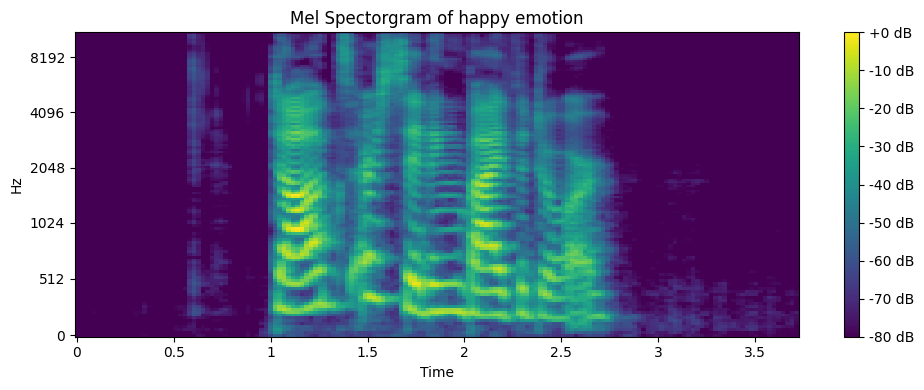

In [4]:
import matplotlib.pyplot as plt
import numpy as np

mel_spec = librosa.feature.melspectrogram(
        y=audio, 
        sr=sr, 
        n_mels=128,
        n_fft=2048,
        hop_length=512
    )
mel_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_db, x_axis='time', y_axis='mel', cmap='viridis')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectorgram of happy emotion")
plt.tight_layout()
plt.show()
    

In [5]:
sad_audio_file = "03-01-04-01-02-02-02"

try:
    sad_audio, sad_sr = librosa.load(f"audio_files/{sad_audio_file}.wav")
    sad_audio = librosa.util.normalize(sad_audio)
except Exception as e:
    print(f"Error occured: {e}")

librosa.get_duration(y=sad_audio, sr=sad_sr)

3.7704761904761903

In [6]:
df.loc[df["file_name"] == sad_audio_file]

,file_name,emotion,intensity,gender,statement,duration
1128,03-01-04-01-02-02-02,sad,normal,female,Dogs are sitting by the door,3.770437


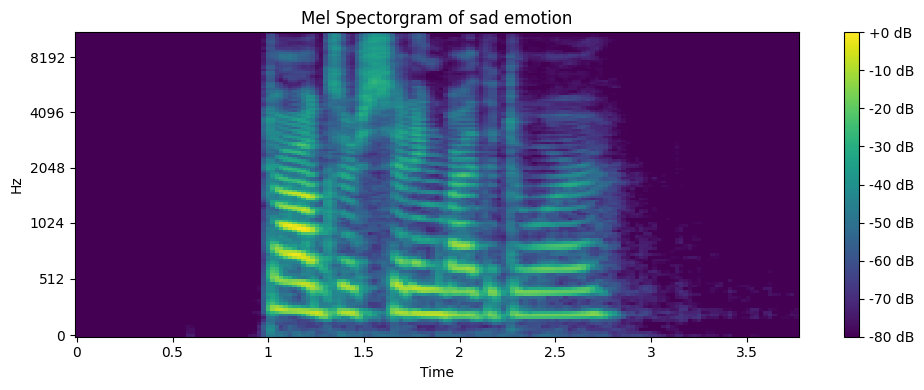

In [7]:
mel_spec_sad = librosa.feature.melspectrogram(
        y=sad_audio, 
        sr=sad_sr, 
        n_mels=128,
        n_fft=2048,
        hop_length=512
    )
mel_db_sad = librosa.power_to_db(mel_spec_sad, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_db_sad, x_axis='time', y_axis='mel', cmap='viridis')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectorgram of sad emotion")
plt.tight_layout()
plt.show()